# Analyse

本notebook的目的在于分析DIA-NN和pFind的鉴定结果，对DIA-NN鉴定到而pFind未鉴定到的（可信）肽段的进行归因

In [2]:
from utils import *
import os

In [3]:
raws = [
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_01_20230808155512.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_02_20230808161140.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_03_20230808162807.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top75_01_20230808171732.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top75_02_20230808173359.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top75_03_20230808175026.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top100_01.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top100_02.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top100_03.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_Cycle_01_20230808143253.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_Cycle_02_20230808144922.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_Cycle_03_20230808150548.raw",
]
raw_paths = raws[:3]
# raw_paths = raws[3:6]
# raw_paths = raws[6:9]
# raw_paths = raws[9:]

In [5]:
pep_level_fdr = 0.01
ppm_level = 10
P_mass = 1.007277  # 质子相对质量
mod_ini_path = "infos/modification.ini"
mod_uni_path = "infos/unimod.obo.txt"
pfc_paths = [path.replace('.raw', '.pfc') for path in raw_paths]
csv_paths = [path.replace('.raw', '.csv') for path in raw_paths]
mgf_paths = [path.replace('.raw', '_HCDAST.mgf') for path in raw_paths]
ms1_paths = [path.replace('.raw', '.ms1') for path in raw_paths]
# pfind_res_path = os.path.join(pfind_res_dir,"pFind.spectra")

mod2unimod_id = get_mod2unimod_id(mod_ini_path, mod_uni_path)
ms2_diann2pfind, pfind_ms2toms1 = get_scan_mapping(pfc_paths)

top50_01
top50_02
top50_03


## 数据准备

In [6]:
"""
获取ms2->ms1的映射(pFind)
"""
raw2ms1s = dict()  # shortened_name -> [ms1,...]
raw2ms1toidx = dict()  # shortened_name -> ms1toidx: ms1->idx(在raw2ms1s[shortened_name]中的下标)
for pfc_path in pfc_paths:
    shortened_name = shorten_name(pfc_path)
    print(shortened_name)
    
    ms1s = list()
    ms1toidx = dict()
    with open(pfc_path, "r") as f:
        next(f, None)
        while True:
            line = f.readline()
            if not line:
                break
            items = line.strip().split("\t")
            if items[3] == "MS1":
                ms1 = items[0]
                ms1s.append(ms1)
                ms1toidx[ms1] = len(ms1s)-1
        raw2ms1s[shortened_name] = ms1s
        raw2ms1toidx[shortened_name] = ms1toidx

top50_01
top50_02
top50_03


In [7]:
"""
获取ms1的谱峰：ms1topeaks
"""
ms1topeaks = dict()
for ms1_path in ms1_paths:
    shortened_name = shorten_name(ms1_path)
    print(shortened_name)

    pfind_ms1 = None
    fr = open(ms1_path, "r")
    for line in fr:
        if line.startswith("S"):
            if pfind_ms1 is not None:
                ms1topeaks[pfind_ms1] = peaks
            idx = int(line.strip().split("\t")[1])
            pfind_ms1 = shortened_name + "-" + str(idx)
            peaks = list()
        elif "A" <= line[0] <= "Z":
            continue
        else:
            mz, intensity = line.strip().split()
            mz, intensity = float(mz), float(intensity)
            peaks.append((mz,intensity))

    # 尾部情况
    if pfind_ms1 is not None:
        ms1topeaks[pfind_ms1] = peaks
    fr.close()

top50_01
top50_02
top50_03


## 对于未导出母离子谱图的分析

    pfind_res: idx->[[seq,modified_seq,charge,is_decoy,cal_mh,exp_mh,q_value]]

    diann_res: idx->[[seq,modified_seq,charge,is_decoy,cal_mz,q_value]]

    注意：idx, seq, modified_seq, is_decoy已对齐

    pfind_res包含全部鉴定结果(不卡FDR),DIA-NN仅包含FDR阈值下的结果

    根据pfind.spectra的特点，显然某个idx对应的肽段结果(混合谱)都是按q_value从小到大排序好的

    focused_spectra: [[pfind_idx,seq,modified_seq,charge,cal_mz,protein_names,problem],...]

In [8]:
"""
查找同位素峰簇的个数(以target_mz为单同位素峰，查找连续同位素峰簇数目)
"""
def find_isotopes(peaks, target_mz, charge, ppm=10):
    isotopes = [target_mz+i*(1/charge) for i in range(10)]  # 给10个同位素峰簇好吧

    num = 0
    for mz in isotopes:
        flag = False
        left_mz = mz*(1-1e-6*ppm)
        right_mz = mz*(1+1e-6*ppm)
        left, right = 0, len(peaks)
        while left<right:
            mid = (left+right)//2
            if left_mz<=peaks[mid][0]<=right_mz:
                num += 1
                flag = True
                break
            elif peaks[mid][0]<target_mz:
                left = mid+1
            else:
                right = mid
        if not flag:  # 要求连续同位素峰簇
            break
    return num


def search_mz1(peaks, target_mz, ppm=10):
    left_mz = target_mz*(1-1e-6*ppm)
    right_mz = target_mz*(1+1e-6*ppm)
    left, right = 0, len(peaks)
    while left<right:
        mid = (left+right)//2
        if left_mz<=peaks[mid][0]<=right_mz:
            return True
        elif peaks[mid][0]<target_mz:
            left = mid+1
        else:
            right = mid
    return False

In [9]:
"""
检查DIA-NN多鉴定出的可信肽段对应于pFind未导出对应母离子的谱图，查看它未导出的原因，分析具体情况：
1. 在各窗口中出现的次数计数
2. 最近出现在哪个窗口中
3. 是否存在同位素谱峰
"""
shortened_name = shorten_name(raw_paths[0])
focused_spectra_path = f"data/{shortened_name.split('_')[0]}_focused_spectra_conf.txt"
mass_problem_spectra = list()
with open(focused_spectra_path, "r") as f:
    for line in f:
        pfind_idx, seq, modified_seq, charge, cal_mz, protein_names, problem = line.strip().split("\t")
        if problem != "mass":
            continue
        charge, cal_mz = int(charge), float(cal_mz)
        mass_problem_spectra.append((pfind_idx,seq,modified_seq,charge,cal_mz,protein_names))


window_size = 10  # 左右各window_size个窗口
ppm = 10

ms1_window_cnt = [0] * (2*window_size+1)  # 落入窗口计数
ms1_nearest_cnt = [0] * (2*window_size+1)  # 落入最近窗口计数
not_find_cnt = 0  # 窗口内ms1均没找到对应谱峰
a = 0
isotope_nums = list()  # 单张一级谱中最大同位素峰数目
isotope_nums_cross = list()  # 窗口中出现的最大同位素峰数目
find_window_nums = list()  # 能在多少个window中找到对应母离子质荷比
for spectrum_info in mass_problem_spectra:
    a += 1
    if a % 10000 == 0:
        print(a)
    pfind_idx, seq, modified_seq, charge, cal_mz, protein_names = spectrum_info
    shortened_name, ms2 = pfind_idx.split("-")
    # print(ms2, type(ms2))
    ms1 = pfind_ms2toms1[shortened_name][ms2]
    ms1_idx = raw2ms1toidx[shortened_name][ms1]

    window_ms1s = list()
    # 1.查找母离子质荷比 & 单张一级谱中最大同位素峰数目
    find_window = [False] * (2*window_size+1)
    max_isotope_num = 0
    ## 中心是否有峰
    window_ms1s.append(shortened_name+"-"+ms1)
    isotope_num = find_isotopes(ms1topeaks[shortened_name+"-"+ms1], cal_mz, charge, ppm=ppm)
    if isotope_num > 0:  # 有峰
        max_isotope_num = max(max_isotope_num, isotope_num)
        find_window[window_size] = True
        ms1_window_cnt[window_size] += 1
    ## 中心的窗口是否有峰
    for k in range(1, window_size+1):
        i, j = ms1_idx-k, ms1_idx+k
        if i >= 0:  # 左侧窗口
            i_idx = shortened_name+"-"+raw2ms1s[shortened_name][i]
            window_ms1s.append(i_idx)
            isotope_num = find_isotopes(ms1topeaks[i_idx], cal_mz, charge, ppm=ppm)
            if isotope_num > 0:  # 有峰
                max_isotope_num = max(max_isotope_num, isotope_num)
                find_window[window_size-k] = True
                ms1_window_cnt[window_size-k] += 1
        if j < len(raw2ms1s[shortened_name]):  # 右侧窗口
            j_idx = shortened_name+"-"+raw2ms1s[shortened_name][j]
            window_ms1s.append(j_idx)
            isotope_num = find_isotopes(ms1topeaks[j_idx], cal_mz, charge, ppm=ppm)
            if isotope_num > 0:  # 有峰
                max_isotope_num = max(max_isotope_num, isotope_num)
                find_window[window_size+k] = True 
                ms1_window_cnt[window_size+k] += 1
    isotope_nums.append(max_isotope_num)
    
    # 2.找到最近窗口
    flag = False
    for k in range(window_size+1):
        if find_window[window_size-k] and find_window[window_size+k]:
            ms1_nearest_cnt[window_size-k] += 0.5
            ms1_nearest_cnt[window_size+k] += 0.5
            flag = True
            break
        elif find_window[window_size-k]:
            ms1_nearest_cnt[window_size-k] += 1
            flag = True
            break
        elif find_window[window_size+k]:
            ms1_nearest_cnt[window_size+k] += 1
            flag = True
            break
            
    # 3.找到有多少个窗口中有目标母离子质荷比
    find_window_num = sum(find_window)
    find_window_nums.append(find_window_num)
    
    # 4.窗口内所有一级谱中出现的最大同位素峰数目
    max_isotope_num_cross = 0
    isotopes = [cal_mz+i*(1/charge) for i in range(4)]
    for isotope in isotopes:
        num = 0
        max_conti_num = 0
        conti_num = 0
        for m in window_ms1s:
            if search_mz1(ms1topeaks[m], isotope, ppm=ppm):
                num += 1
                conti_num += 1
                max_conti_num = max(max_conti_num,conti_num)
            else:
                conti_num = 0
        if (num >= 1) and (num >= 5 or num >= find_window_num-1):  # 判断准则
        # if max_conti_num >= 2:
            max_isotope_num_cross += 1
        else:
            break
    isotope_nums_cross.append(max(max_isotope_num_cross,max_isotope_num))

    # assert not (max_isotope_num_cross != 0 and not flag)
    # 5.一个匹配谱峰也没有
    if not flag:
        not_find_cnt += 1
    # break

10000
20000
30000


In [10]:
# print(len(mass_problem_spectra), not_find_cnt, ms1_window_cnt, ms1_nearest_cnt, isotope_nums)
# lkl = 0
# for i in isotope_nums:
#     lkl = max(lkl, i)
# lkl
print(len(mass_problem_spectra),not_find_cnt)
# isotope_nums_cross

30147 839


### 绘图

[('0', 839), ('1', 11031), ('2', 15604), ('>2', 2673)]


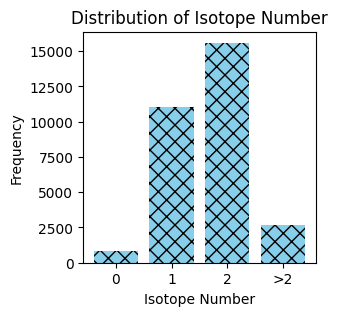

In [11]:
"""
单张一级谱中最大同位素峰数目分布
"""
import matplotlib.pyplot as plt
frequency = {">2":0}
for num in isotope_nums:
    if num > 2:
        frequency[">2"] += 1
        continue
    if str(num) in frequency:
        frequency[str(num)] += 1
    else:
        frequency[str(num)] = 1
frequency = sorted(frequency.items(), key=lambda item: item[0])

print(frequency)

# 提取 x 轴和 y 轴的值
x = [x for x,y in frequency]
y = [y for x,y in frequency]
 
# 绘制条形图
plt.figure(figsize=(3,3))
plt.bar(x, y, color='skyblue',hatch='xx')
plt.title('Distribution of Isotope Number')
plt.xlabel('Isotope Number')
plt.ylabel('Frequency')
plt.show()

In [12]:
# """
# 单张一级谱中最大同位素峰数目分布(箱线图)
# """
# import matplotlib.pyplot as plt
# # frequency = {">3":0}
# # for num in isotope_nums:
# #     if num > 3:
# #         frequency[">3"] += 1
# #         continue
# #     if str(num) in frequency:
# #         frequency[str(num)] += 1
# #     else:
# #         frequency[str(num)] = 1
# # frequency = sorted(frequency.items(), key=lambda item: item[0])

# # 给定一个数字列表，全部为0到21之间的整数
# data_group1 = isotope_nums

# # 创建一个图形和一个子图
# fig, ax = plt.subplots(figsize=(5,3))

# # 绘制箱线图
# boxplot = ax.boxplot(data, vert=True, patch_artist=True, labels=["top50"])

# # 可选：设置箱线图的颜色
# colors = ['pink', 'lightblue', 'lightgreen', 'lightyellow', 'purple']
# for patch, color in zip(boxplot['boxes'], colors):
#     patch.set_facecolor(color)

# # 添加标题和标签（可选）
# ax.set_title('Boxplot of Random Integers between 0 and 21')
# ax.set_xlabel('Experiments')  # 通常这里可以设置为更具体的标签，但因为是随机数据，所以用'Sample'代替
# ax.set_ylabel('Frequency')

# # 显示图形
# plt.show()

[('0', 839), ('1', 4210), ('2', 9431), ('>2', 15667)]


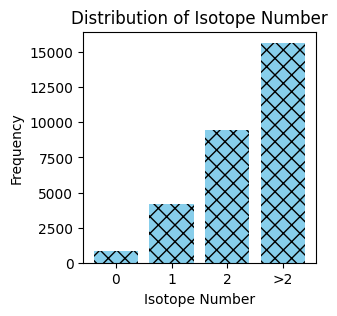

In [13]:
"""
窗口中出现的最大同位素峰数目分布
"""
import matplotlib.pyplot as plt
frequency = {">2":0}
for num in isotope_nums_cross:
    if num > 2:
        frequency[">2"] += 1
        continue
    if str(num) in frequency:
        frequency[str(num)] += 1
    else:
        frequency[str(num)] = 1
frequency = sorted(frequency.items(), key=lambda item: item[0])

print(frequency)

# 提取 x 轴和 y 轴的值
x = [x for x,y in frequency]
y = [y for x,y in frequency]

# 绘制条形图
plt.figure(figsize=(3,3))
plt.bar(x, y, color='skyblue',hatch='xx')
plt.title('Distribution of Isotope Number')
plt.xlabel('Isotope Number')
plt.ylabel('Frequency')
plt.show()

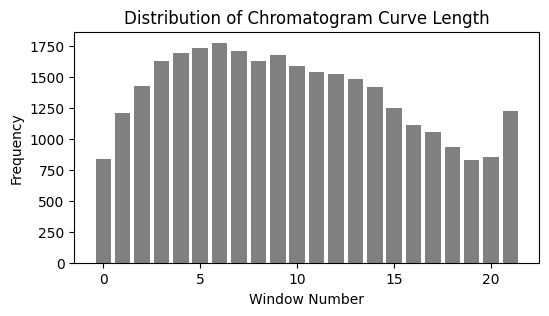

In [14]:
"""
目标母离子落入窗口中的次数分布(直方图)
"""
import matplotlib.pyplot as plt

frequency = {}
for num in find_window_nums:
    if num in frequency:
        frequency[num] += 1
    else:
        frequency[num] = 1
 
# 提取 x 轴和 y 轴的值
x = list(frequency.keys())
y = list(frequency.values())
 
# 绘制条形图
plt.figure(figsize=(6,3))
plt.bar(x, y, color='grey')
plt.title('Distribution of Chromatogram Curve Length')
plt.xlabel('Window Number')
plt.ylabel('Frequency')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_34884\693739225.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(data, vert=True, patch_artist=True, labels=["top50", "top75", "top100", "cycle"])


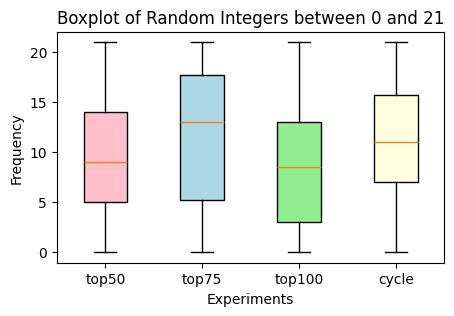

In [15]:
"""
目标母离子落入窗口中的次数分布(箱线图)
"""
import matplotlib.pyplot as plt
import numpy as np

# 给定一个数字列表，全部为0到21之间的整数
data_group1 = find_window_nums
data_group2 = [np.random.randint(0, 22) for _ in range(50)]
data_group3 = [np.random.randint(0, 22) for _ in range(50)]
data_group4 = [np.random.randint(0, 22) for _ in range(50)]
data = [data_group1, data_group2, data_group3, data_group4]

# 创建一个图形和一个子图
fig, ax = plt.subplots(figsize=(5,3))

# 绘制箱线图
boxplot = ax.boxplot(data, vert=True, patch_artist=True, labels=["top50", "top75", "top100", "cycle"])

# 可选：设置箱线图的颜色
colors = ['pink', 'lightblue', 'lightgreen', 'lightyellow', 'purple']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# 添加标题和标签（可选）
ax.set_title('Boxplot of Random Integers between 0 and 21')
ax.set_xlabel('Experiments')  # 通常这里可以设置为更具体的标签，但因为是随机数据，所以用'Sample'代替
ax.set_ylabel('Frequency')

# 显示图形
plt.show()

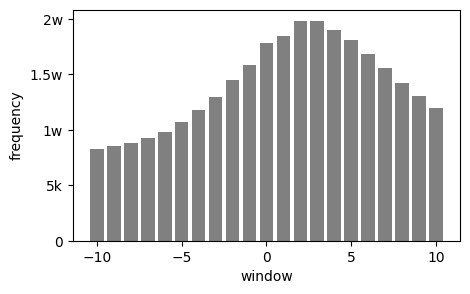

In [16]:
"""
目标母离子质荷比落入窗口内的频次计数
"""
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(5,3))
ax.bar(list(range(-window_size,window_size+1)), ms1_window_cnt, color="grey")  #, hatch="xx", edgecolor="blue")
# plt.title(f"window size=±{window_size}, ppm={ppm}")
ax.set_yticks([0,5000,10000,15000,20000])
ax.set_yticklabels(["0","5k","1w","1.5w","2w"])
ax.set_xlabel("window")
ax.set_ylabel("frequency")
plt.show()

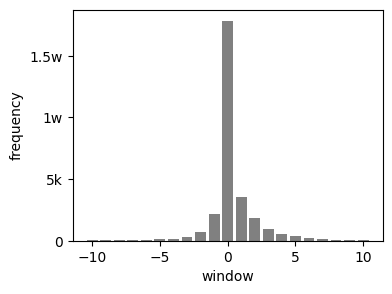

In [17]:
"""
目标母离子质荷比落入最近窗口内的频次计数
"""
fig, ax = plt.subplots(figsize=(4,3))
ax.bar(list(range(-window_size,window_size+1)), ms1_nearest_cnt, color="grey")
# plt.yticks(["5k","1w","1.5w","2w","3"])
ax.set_yticks([0,5000,10000,15000])
ax.set_yticklabels(["0","5k","1w","1.5w"])
# ax.set_title(f"window size=±{window_size}, ppm={ppm}")
ax.set_xlabel("window")
ax.set_ylabel("frequency")
plt.show()

## 对新增谱图(未导出母离子的可信谱图)进行搜索

In [200]:
pfind_res_dir = "D:/pFindWorkspace/Astral/after/new/top50_confident_selectpeak=200_pepnum=10/result/"
# pfind_res_dir = "D:/pFindWorkspace/Astral/pFindTask6-open-Astral-PXD046357-top75/result/"
# pfind_res_dir = "D:/pFindWorkspace/Astral/pFindTask7-open-Astral-PXD046357-top100/result/"
# pfind_res_dir = "D:/pFindWorkspace/Astral/pFindTask8-open-Astral-PXD046357-cycle/result/"

pfind_res_path = os.path.join(pfind_res_dir, "pFind.spectra")

In [201]:
"""
获取结果idx2diann_res: pfind_idx -> pfind_idx -> [(modified_seq,charge,mh), ...]
"""
idx2diann_res = dict()
for spectrum_info in mass_problem_spectra:
    pfind_idx, seq, modified_seq, charge, cal_mz, protein_names = spectrum_info
    cal_mh = cal_mz*charge-(charge-1)*P_mass
    if pfind_idx in idx2diann_res.keys():  # pfind_idx可以对应于多个母离子
        idx2diann_res[pfind_idx].append((modified_seq,charge,mh))
    else:
        idx2diann_res[pfind_idx] = [(modified_seq,charge,mh)]

In [202]:
"""
function:
    读取pFind的topk结果(包括细打分结果.sa和重打分结果.qry.res)：pfind_idx -> topk: pfind_idx -> [(topk_modified_seqs,charge,mh),...]
    topk_modified_seqs = [(rank,modified_seq),...]
    +alignment
"""
def get_idx2pfind_topk_res(res_paths, mod2unimod_id):
    idx2pfind_topk_res = dict()  # pfind_idx -> [(topk_peptides,charge,mh),...]
    for res_path in res_paths:
        pfind_idx = None
        print(res_path)
        fr = open(res_path, "r")
        while True:
            line = fr.readline()
            if not line:
                if pfind_idx not in idx2pfind_topk_res.keys():
                    idx2pfind_topk_res[pfind_idx] = [(modified_seqs,charge,mh)]
                else:
                    idx2pfind_topk_res[pfind_idx].append((modified_seqs,charge,mh))
                break
            items = line.strip().split("\t")
            if items[0] == "S":
                if pfind_idx is None:
                    mh = float(items[1])
                    charge = int(items[2])
                    continue
                if pfind_idx not in idx2pfind_topk_res.keys():
                    idx2pfind_topk_res[pfind_idx] = [(modified_seqs,charge,mh)]
                else:
                    idx2pfind_topk_res[pfind_idx].append((modified_seqs,charge,mh))
                mh = float(items[1])
                charge = int(items[2])
            elif items[0].endswith(".dta"):  # title
                file_id = shorten_name(items[0])
                idx = items[0].split(".")[-4]
                pfind_idx = file_id + "-" + idx
                modified_seqs = list()
            else:
                rank = int(items[0])
                seq = items[1]
                mod_num = int(items[6])
                mod = ""
                for i in range(mod_num):
                    mod += (items[7+2*i] + "," + items[8+2*i].split("#")[0] + ";")
                modified_seq = mod_pfind2diann(seq, mod, mod2unimod_id)
                modified_seqs.append((rank,modified_seq))
        fr.close()
    
    
    """
    Alignment: 一个pfind_idx可能对应多个PSM结果，因此需要将idx2pfind_topk_res向idx2diann_res进行对齐
    """
    _idx2pfind_topk_res = dict()
    for pfind_idx, pfind_topk_res in idx2pfind_topk_res.items():
        diann_res = idx2diann_res[pfind_idx]
        
        assert len(diann_res) == len(pfind_topk_res)
        diann_find = [False] * len(diann_res)
        _pfind_topk_res = list()
        for i in range(len(pfind_topk_res)):  # pfind_idx可能对应于多个PSM
            selected_id = -1
            selected_diff = 1e6
            for j in range(len(diann_res)):
                if not diann_find[j] and abs(pfind_topk_res[i][2]-diann_res[j][2]) < selected_diff:
                    selected_id = j
                    selected_diff = abs(pfind_topk_res[i][2]-diann_res[j][2])
            assert selected_diff < 1e-3
            diann_find[selected_id] = True
            _pfind_topk_res.append(pfind_topk_res[selected_id])
        _idx2pfind_topk_res[pfind_idx] = _pfind_topk_res
    
    return _idx2pfind_topk_res


"""
获取重打分结果(qry.res): idx2pfind_rerank_res: pfind_idx -> [(modified_seqs,charge,mh),...]
"""
rerank_paths = [
    os.path.join(pfind_res_dir, filename) for filename in os.listdir(pfind_res_dir) if filename.endswith("qry.res")
]
idx2pfind_rerank_res = get_idx2pfind_topk_res(rerank_paths, mod2unimod_id)

D:/pFindWorkspace/Astral/after/new/top50_confident_selectpeak=200_pepnum=10/result/top50_confident_selectpeak=200_pepnum=10.F1.L1.qry.res
D:/pFindWorkspace/Astral/after/new/top50_confident_selectpeak=200_pepnum=10/result/top50_confident_selectpeak=200_pepnum=10.F2.L1.qry.res
D:/pFindWorkspace/Astral/after/new/top50_confident_selectpeak=200_pepnum=10/result/top50_confident_selectpeak=200_pepnum=10.F3.L1.qry.res


AssertionError: 

In [205]:
"""
function:
    读取pFind的top1结果：pfind_idx -> topk: pfind_idx -> [(modified_seq,charge,mh,q_value),...]
    +alignment
"""
def get_idx2pfind_res(res_path, mod2unimod_id, pep_level_fdr=1024):
    print(res_path)
    
    idx2pfind_res = dict()
    
    fr = open(res_path, "r")
    next(fr,None)
    while True:
        line = fr.readline()
        if not line:
            break
        items = line.strip().split("\t")
        
        q_value = float(items[4])
        if len(items) <= 5 or q_value > pep_level_fdr:
            break
        # print(items)
        file_id = shorten_name(items[0])
        idx = items[0].split(".")[-4]
        pfind_idx = file_id + "-" + idx
        
        mh = float(items[2])  # 理论mh
        charge = int(items[3])
        seq = items[5]
        mod = items[10]
        modified_seq = mod_pfind2diann(seq, mod, mod2unimod_id)
        if pfind_idx not in idx2pfind_res.keys():
            idx2pfind_res[pfind_idx] = list()
        idx2pfind_res[pfind_idx].append((modified_seq,charge,mh,q_value))
    fr.close()
    
    """
    Alignment: 一个pfind_idx可能对应多个PSM结果，因此需要将idx2pfind_res向idx2diann_res进行对齐
    """
    _idx2pfind_res = dict()
    for pfind_idx, pfind_res in idx2pfind_res.items():
        diann_res = idx2diann_res[pfind_idx]
        
        assert len(diann_res) == len(pfind_res)
        diann_find = [False] * len(diann_res)
        _pfind_res = list()
        for i in range(len(pfind_res)):  # pfind_idx可能对应于多个PSM
            selected_id = -1
            selected_diff = 1e6
            for j in range(len(diann_res)):
                if not diann_find[j] and abs(pfind_res[i][2]-diann_res[j][2]) < selected_diff:
                    selected_id = j
                    selected_diff = abs(pfind_res[i][2]-diann_res[j][2])
            if selected_diff > 1e-3:
                print(selected_diff)
            assert selected_diff < 1e-3
            diann_find[selected_id] = True
            _pfind_res.append(pfind_res[selected_id])
        _idx2pfind_res[pfind_idx] = _pfind_res
        
    return _idx2pfind_res


"""
获取pFind最终结果(pFind.spectra)，包括通过和未通过阈值的
idx2pfind_res: pfind_idx -> [[seq,modified_seq,charge,is_decoy,cal_mh,exp_mh,q_value,protein_names]...]
"""
idx2pfind_res = get_idx2pfind_res(pfind_res_path, mod2unimod_id)

D:/pFindWorkspace/Astral/after/new/top50_confident_selectpeak=200_pepnum=10/result/pFind.spectra
561.3479169999998


AssertionError: 

In [170]:
# cal_precursor_mh("LMQIQPNREDTETLIK",aa2mass)
cal_precursor_mh("LQNVDIELDAARSELSR",aa2mass)

1929.0035001999997

In [188]:
idx2pfind_rerank_res["top50_01-17134"]

[([(1, 'GGGFGGNDNFGR'),
   (2, 'GFNDNGGFGGGR'),
   (3, 'GNGNNTTMMSK'),
   (4, 'KGC(UniMod:4)SEDCSIR'),
   (5, '(UniMod:1)SMDDDFGVVK'),
   (6, 'ERDSCEYPR'),
   (7, 'GSVTDEEFDR'),
   (8, 'DKCDM(UniMod:35)ATAAGR'),
   (9, 'MTCEGC(UniMod:4)VGAVK'),
   (10, '(UniMod:1)GGGPSPCGPGGGGR')],
  2,
  1154.494488),
 ([(1, 'KDFTQLFPR'),
   (2, 'ITDNSHLVPR'),
   (3, 'AGGGGGGGGVAPPLK'),
   (4, 'LTMFRENLK'),
   (5, '(UniMod:1)EAPAERALPR'),
   (6, 'TIFGRPGTFR'),
   (7, 'ELGRRPMHR'),
   (8, '(UniMod:1)KMAPPKNAPR'),
   (9, 'FKM(UniMod:35)KDTLPR'),
   (10, '(UniMod:1)TPRPTSPTPR')],
  2,
  1151.627806),
 ([(1, 'HHHYFGGLGK'),
   (2, 'DAGPEPDKAPR'),
   (3, 'GFEDLLCLSR'),
   (4, 'DPASPAPTSGPR'),
   (5, 'GGGSSSVVSYPR'),
   (6, 'FDRLHDGHR'),
   (7, '(UniMod:1)VDEYSSLAVK'),
   (8, 'TAAAASSIM(UniMod:35)GTR'),
   (9, '(UniMod:1)SNPAIC(UniMod:4)RHR'),
   (10, 'RSTC(UniMod:4)AAM(UniMod:35)LAR')],
  2,
  1152.572052),
 ([], 2, 1153.072974),
 ([(1, 'MNVYSDNGPR'),
   (2, 'ESAAMLNNM(UniMod:35)R'),
   (3, 'C(UniMod:4)DFAP

In [181]:
mgf_paths = ["D:/data/ms/Astral/PXD046357-Single_Cell_after/AST_DDA_HeLa__top50_01_20230808155512_conf.mgf"]
idx2peaks = get_idx2peaks(mgf_paths)

D:/data/ms/Astral/PXD046357-Single_Cell_after/AST_DDA_HeLa__top50_01_20230808155512_conf.mgf


In [207]:
peaks = list
peaks = sorted(idx2peaks["top50_01-47806"], key=lambda item:item[1], reverse=True)
ratio = peaks[199][1] / peaks[0][1]
ratio

0.013983259822830864